# Introduction

This Notebook introduces Gemma 4:E2B (it).

In a [previous Notebook](https://www.kaggle.com/code/gpreda/test-gemma-4-e2b-on-cpu), we just tested it on CPU.

Here we will run more tests, using Kaggle GPUs free tier.

## About Gemma

Recently Gemma 4 was released. Their capabilities include OCR, speech-to-text, object detection. They also support text-only, multimodal function calling, as well as reasoning, code completion, and correction.

Here are the features of each model:

* Gemma 4 E2B — has a context window of 128K. Parameter size is 2.3B effective, 5.1B with embeddings.
* Gemma 4 E4B — has a context window of 128K. Parameter size is 4.5B effective, 8B with embeddings.
* Gemma 4 26B — mixture of experts with 4B activated/26 total parameters. Context window in 256K.
* Gemma 4 31B — it is a 31B dense model, with context window 256K.
All models have both base and it versions. We will use Ollama on a local machine to run Gemma 4 E2B.


<center><img src="https://storage.googleapis.com/gweb-uniblog-publish-prod/images/gemma-4_blog_keyword_meta-dark.width-1300.png" width=600></center>



# Upgrade transformers

In [1]:
!pip install -U transformers  -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 637.4/637.4 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 97.9 MB/s eta 0:00:00


# Import packages

In [2]:
from time import time
from IPython.display import Markdown
import requests
from PIL import Image
import kagglehub
import torch
from transformers import AutoProcessor, AutoModelForCausalLM

# Initialize model

In [3]:
MODEL_PATH = kagglehub.model_download("google/gemma-4/transformers/gemma-4-e2b-it")

processor = AutoProcessor.from_pretrained(MODEL_PATH)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    dtype=torch.bfloat16,
    device_map="auto"
)

Loading weights:   0%|          | 0/2011 [00:00<?, ?it/s]

# Test with text input

In [4]:
messages = [
    {"role": "system", "content": "You are a helpful assistant that specializes in answering shortly to any question."},
    {"role": "user", "content": "When we first walked on the Moon?"},
]

s_time = time()
text = processor.apply_chat_template(
    messages, 
    tokenize=False, 
    add_generation_prompt=True, 
    enable_thinking=True
)
inputs = processor(text=text, return_tensors="pt").to(model.device)
input_len = inputs["input_ids"].shape[-1]


outputs = model.generate(**inputs, max_new_tokens=1024)
response = processor.decode(outputs[0][input_len:], skip_special_tokens=False)

processor.parse_response(response)
e_time = time()
total_time = round(e_time - s_time, 2)
print(f"Total time: {total_time}")

Total time: 15.72


Let's display the output more user friendly.

In [5]:
output = processor.parse_response(response)

# Format the output

In [6]:
def colorize_text(text):
    for word, color in zip(["Thinking", "Thinking Process", "Response", "Total time"], ["blue", "red", "green", "magenta"]):
        text = text.replace(f"{word}:", f"\n\n**<font color='{color}'>{word}:</font>**")
    return text
    
def display_response(output, total_time):
    if output.get('thinking'):
        display(Markdown(f"<font color='green'>Thinking</font>"))
        display(Markdown(colorize_text(output["thinking"])))
    if output.get('content'):
        display(Markdown(f"<font color='blue'>Response</font>"))
        display(Markdown(output["content"]))
    display(Markdown(colorize_text(f"Total time: {total_time} sec.")))

In [7]:
display_response(output, total_time)

<font color='green'>Thinking</font>



**<font color='red'>Thinking Process:</font>**

1.  **Analyze the Request:** The user is asking, "When we first walked on the Moon?" (This refers to the Apollo 11 mission).
2.  **Determine the Core Information Needed:** I need the date of the first Moon landing.
3.  **Recall/Verify the Fact:** The first Moon landing occurred in July 1969. Specifically, July 20, 1969.
4.  **Format the Answer (Constraint Check):** The instruction is to "answer shortly."
5.  **Draft the 

**<font color='green'>Response:</font>**** State the date clearly and concisely.

*(Self-Correction/Refinement):* Keep it direct.

6.  **Final Output Generation.**

<font color='blue'>Response</font>

July 20, 1969.



**<font color='magenta'>Total time:</font>** 15.72 sec.

# Multi-language tests


Let's first test with Romanian, my mother tongue.

In [8]:
messages = [
    {"role": "system", "content": "Ești un agent AI care răspunde în limba română."},
    {"role": "user", "content": "Cine a fost Nadia Comaneci?"},
]

s_time = time()
text = processor.apply_chat_template(
    messages, 
    tokenize=False, 
    add_generation_prompt=True, 
    enable_thinking=True
)
inputs = processor(text=text, return_tensors="pt").to(model.device)
input_len = inputs["input_ids"].shape[-1]


outputs = model.generate(**inputs, max_new_tokens=1024)
response = processor.decode(outputs[0][input_len:], skip_special_tokens=False)

output = processor.parse_response(response)
e_time = time()
total_time = round(e_time - s_time, 2)
print(f"Total time: {total_time}")

Total time: 42.93


In [9]:
display_response(output, total_time)

<font color='green'>Thinking</font>



**<font color='red'>Thinking Process:</font>**

1.  **Analyze the Request:** The user is asking in Romanian, "Cine a fost Nadia Comaneci?" (Who was Nadia Comăneci?).
2.  **Identify the Subject:** Nadia Comăneci.
3.  **Determine Key Information:** Who is she? (A gymnast). What is she famous for? (Her achievements, especially winning medals and breaking records). What was her significance? (Symbol of Romanian gymnastics, Olympic success).
4.  **Formulate the Answer (in Romanian):**
    *   Start with a direct identification.
    *   Mention her sport (gymnastics).
    *   Highlight her major achievements (Olympics, records, titles).
    *   Mention her impact (iconic status).
5.  **Draft the Response (Self-Correction/Refinement):** Ensure the tone is informative and respectful.

    *   *Initial thought:* Nadia Comăneci este o gimnastică. A câștigat multe medii.
    *   *Refinement (More detailed and engaging):* Need to mention *how* she became famous (the specific achievements).

6.  **Final Output Generation (in Romanian):** (This matches the desired detailed response.)

<font color='blue'>Response</font>

Nadia Comăneci a fost o gimnastică română, considerată una dintre cele mai mari și cele mai influente figuri din istoria sportului.

Iată câteva aspecte cheie despre ea:

* **Excelență Sportivă:** Este recunoscută pentru tehnica sa impecabilă, precizia și forța fizică extraordinară. A fost considerată o erouină a gimnasticismului.
* **Succese Olimpice:** Cea mai mare realizare a ei a fost participarea ei la Olimpiada din Montreal în 1976, unde a adus în deplasare o serie de medalii, inclusiv medalia de aur la arcum.
* **Răspândirea Standardelor:** Comăneci a adus la sportul de gimnastică un nou nivel de standard și perfecțiune tehnică, inspirând generații de gimnaste.
* **Iconă Culturală:** În plus față de realizările sale sportive, Nadia Comăneci a devenit o figură culturală mondială, simbolizând excelența și disciplinele sportive.

În rezumat, Nadia Comăneci este una dintre cele mai brillante gimnaste din istorie și o iconă a sportului.



**<font color='magenta'>Total time:</font>** 42.93 sec.

Let's check as well with a question in French.

In [10]:
messages = [
    {"role": "system", "content": "Vous êtes un agent IA, répondez uniquement en français."},
    {"role": "user", "content": "Qui était Édith Piaf ?"},
]

s_time = time()
text = processor.apply_chat_template(
    messages, 
    tokenize=False, 
    add_generation_prompt=True, 
    enable_thinking=True
)
inputs = processor(text=text, return_tensors="pt").to(model.device)
input_len = inputs["input_ids"].shape[-1]


outputs = model.generate(**inputs, max_new_tokens=1024)
response = processor.decode(outputs[0][input_len:], skip_special_tokens=False)

output = processor.parse_response(response)
e_time = time()
total_time = round(e_time - s_time, 2)
print(f"Total time: {total_time}")

Total time: 69.17


In [11]:
display_response(output, total_time)

<font color='green'>Thinking</font>

Here's a thinking process that leads to the suggested answer:

1.  **Analyze the Request:** The user is asking, "Who was Édith Piaf?" (Qui était Édith Piaf ?).

2.  **Identify the Subject:** Édith Piaf is a globally recognized figure, primarily a French singer, known for her powerful voice and iconic status.

3.  **Determine Key Information Points (What must be included?):**
    *   Identity (Singer, French).
    *   Career/Era (When was she active?).
    *   Style/Impact (What made her famous? Emotion, style).
    *   Key Achievements (Awards, songs).
    *   Significance (Her legacy).

4.  **Draft Content Points (Mental Outline in French context):**
    *   *Introduction:* Define her status (Icone, chanteuse).
    *   *Early Life/Style:* Humble beginnings, raw emotion in her singing.
    *   *Career Peak:* The "Môme," her distinctive voice, emotional delivery.
    *   *Key Works:* Mention famous songs (La Vie en rose, Non, je ne regrette rien).
    *   *Impact:* Cultural significance, symbol of French chanson.
    *   *Legacy:* Her enduring influence.

5.  **Refine and Elaborate (Structuring the Answer in French):** (Self-Correction: Ensure the tone is respectful and celebratory, reflecting her stature.)

    *   *Initial thought structure:* Start strong, detail the career, conclude with the legacy.

6.  **Final Review against the Prompt:** Does this answer "Who was Édith Piaf?" comprehensively? Yes. Is it in French? Yes.

7.  **Generate Final Response.** (This matches the detailed, structured answer provided below.)

<font color='blue'>Response</font>

Édith Piaf (née Édith Giovanna Gassion) est sans aucun doute l'une des chanteuses les plus emblématiques et les plus célèbres de l'histoire de la musique française. Elle est considérée comme une icône mondiale de la chanson française.

Voici un aperçu de qui elle était :

### 1. Une Icône de la Chanson Française

Piaf est surtout célèbre pour sa voix puissante, pleine d'émotion et de souffrance, et pour sa capacité à transmettre une profondeur humaine incroyable à ses chansons. Elle incarne l'âme et la passion de la France.

### 2. Carrière et Style

* **Débuts modestes :** Sa vie a commencé dans des milieux modestes, mais sa passion pour la musique l'a propulsée au sommet.
* **L'authenticité :** Ce qui a marqué Piaf, c'est son authenticité. Elle chantait ses émotions de manière brute et sincère, ce qui créait une connexion immédiate et profonde avec son public.
* **La "Môme" :** Elle est devenue synonyme de la *chanson réaliste* et de la mélancolie romantique. Elle chantait des histoires d'amour, de désespoir, de joie et de résilience.

### 3. Œuvres Majeures

Elle a popularisé des chansons qui sont devenues des classiques intemporels, telles que :
* **"La Vie en Rose"**
* **"Non, je ne regrette rien"**
* **"Manon"**
* **"L'Accordéoniste"**

### 4. Impact Culturel

Édith Piaf n'était pas seulement une chanteuse ; elle était un phénomène culturel. Elle a transcendé les frontières linguistiques et a été une figure majeure de la culture populaire mondiale. Elle est devenue un symbole de la force féminine, de la résilience et de la beauté tragique.

### En résumé

Édith Piaf était une artiste dont la voix et l'émotion ont créé un pont entre la souffrance humaine et la beauté artistique. Elle reste une figure incontournable de la musique française et un symbole de la passion et de la survie.



**<font color='magenta'>Total time:</font>** 69.17 sec.

# Test with image


We will also test with an image.


<img src="https://storage.googleapis.com/keras-cv/models/paligemma/cow_beach_1.png"></img>



In [12]:
image_url = "https://storage.googleapis.com/keras-cv/models/paligemma/cow_beach_1.png"
image = Image.open(requests.get(image_url, stream=True).raw).convert("RGB")

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": "What you can see in this image?"}
        ]
    }
]
s_time = time()

text = processor.apply_chat_template(
    messages, 
    tokenize=False, 
    add_generation_prompt=True, 
    enable_thinking=True
)
inputs = processor(
    text=text,
    images=image,
    return_tensors="pt"
).to(model.device)

input_len = inputs["input_ids"].shape[-1]

with torch.inference_mode():
    outputs = model.generate(**inputs, max_new_tokens=1024)

response = processor.decode(outputs[0][input_len:], skip_special_tokens=False)
output = processor.parse_response(response)

e_time = time()
total_time = round(e_time - s_time, 2)

print(output)
print(f"Total time: {total_time}")

{'role': 'assistant', 'thinking': 'Here\'s a thinking process to generate the image description:\n\n1.  **Analyze the Request:** The user has provided an image and asked, "What you can see in this image?"\n\n2.  **Examine the Image (Initial Scan):**\n    *   What is the main subject? A cow.\n    *   Where is the cow? On a beach.\n    *   What is the setting/environment? Sunny, blue sky, ocean, sand.\n\n3.  **Detailed Analysis (Focusing on the Subject - The Cow):**\n    *   Color: Brown/tawny coat.\n    *   Markings: White face/muzzle.\n    *   Pose/Action: Standing, looking directly at the camera/viewer.\n    *   Details: Appears healthy, large.\n\n4.  **Detailed Analysis (Focusing on the Setting - Background/Foreground):**\n    *   Foreground: Light-colored sand, wet patches near the waterline.\n    *   Midground: The cow is standing on the sand.\n    *   Background:\n        *   Water: Clear, turquoise/blue ocean.\n        *   Horizon: A distant landmass or coastline (hilly/mountaino

Let's display the output nicely formated.

In [13]:
display_response(output, total_time)

<font color='green'>Thinking</font>

Here's a thinking process to generate the image description:

1.  **Analyze the Request:** The user has provided an image and asked, "What you can see in this image?"

2.  **Examine the Image (Initial Scan):**
    *   What is the main subject? A cow.
    *   Where is the cow? On a beach.
    *   What is the setting/environment? Sunny, blue sky, ocean, sand.

3.  **Detailed Analysis (Focusing on the Subject - The Cow):**
    *   Color: Brown/tawny coat.
    *   Markings: White face/muzzle.
    *   Pose/Action: Standing, looking directly at the camera/viewer.
    *   Details: Appears healthy, large.

4.  **Detailed Analysis (Focusing on the Setting - Background/Foreground):**
    *   Foreground: Light-colored sand, wet patches near the waterline.
    *   Midground: The cow is standing on the sand.
    *   Background:
        *   Water: Clear, turquoise/blue ocean.
        *   Horizon: A distant landmass or coastline (hilly/mountainous).
        *   Sky: Bright blue with some white clouds.
    *   Lighting/Mood: Bright, sunny, tropical, relaxed.

5.  **Synthesize and Structure the Description:** Start with the main subject and move to the environment, adding sensory details (color, mood).

    *   *Drafting Section 1 (The Core Subject):* A brown and white cow.
    *   *Drafting Section 2 (The Location):* Beach, ocean, sand.
    *   *Drafting Section 3 (The Atmosphere/Composition):* Sunny day, blue sky, scenic view.

6.  **Refine the Language (Making it descriptive and engaging):** (Self-Correction/Enhancement: Instead of just "cow," use "bovine" or describe its features. Use strong adjectives for the colors.)

7.  **Final Review against the Image:** (Check if the description accurately reflects all major elements.) Yes, the description covers the cow, the beach, the water, and the sky.

8.  **Generate the Final Output.** (This matches the provided good response.)

<font color='blue'>Response</font>

Based on the image provided, here is a detailed description of what can be seen:

**Main Subject:**
*   The central focus of the image is a **cow** (bovine).
*   The cow has a reddish-brown or tawny coat and a distinct white face and muzzle.
*   It is standing squarely on the sand and is looking directly toward the camera.

**Setting and Environment:**
*   The scene takes place on a **beach**. The foreground consists of light-colored, possibly damp sand.
*   Beyond the sand is the **ocean**, which is a clear, vibrant turquoise or blue color.
*   In the distance, there is a **coastline or landmass** with hills or mountains visible on the horizon.
*   The **sky** is bright blue with some wispy white clouds, indicating a sunny day.

**Atmosphere:**
*   The overall mood of the image is bright, sunny, and tropical or idyllic. The lighting suggests it is midday.

**In summary, the image captures a picturesque scene of a brown and white cow standing on a sunny beach with a turquoise ocean and distant hills in the background.**



**<font color='magenta'>Total time:</font>** 55.2 sec.

The interpretation of the image is accurate.

# Object extraction

Gemma 4 documentation shows that it is great at object detection as well. Lets's check it as well for such a task. We will use a bike image for this:

<img src="https://i.pinimg.com/736x/83/c8/8c/83c88c3408be186525b30c89cfefe704.jpg" width=600></img>


In [14]:
image_url = "https://i.pinimg.com/736x/83/c8/8c/83c88c3408be186525b30c89cfefe704.jpg"
image = Image.open(requests.get(image_url, stream=True).raw).convert("RGB")

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": "What is the bounding box for the bike?"}
        ]
    }
]
s_time = time()

text = processor.apply_chat_template(
    messages, 
    tokenize=False, 
    add_generation_prompt=True, 
    enable_thinking=True
)
inputs = processor(
    text=text,
    images=image,
    return_tensors="pt"
).to(model.device)

input_len = inputs["input_ids"].shape[-1]

with torch.inference_mode():
    outputs = model.generate(**inputs, max_new_tokens=1024)

response = processor.decode(outputs[0][input_len:], skip_special_tokens=False)
output = processor.parse_response(response)

e_time = time()
total_time = round(e_time - s_time, 2)

print(output)
print(f"Total time: {total_time}")

{'role': 'assistant', 'thinking': 'Here are the bounding box detections for the requested objects:\n- bike: [441, 184, 953, 662]', 'content': '```json\n[\n  {"box_2d": [441, 184, 953, 662], "label": "the bike"}\n]\n```'}
Total time: 7.12


In [15]:
display_response(output, total_time)

<font color='green'>Thinking</font>

Here are the bounding box detections for the requested objects:
- bike: [441, 184, 953, 662]

<font color='blue'>Response</font>

```json
[
  {"box_2d": [441, 184, 953, 662], "label": "the bike"}
]
```



**<font color='magenta'>Total time:</font>** 7.12 sec.

Let's check this is true.

(np.float64(-0.5), np.float64(735.5), np.float64(502.5), np.float64(-0.5))

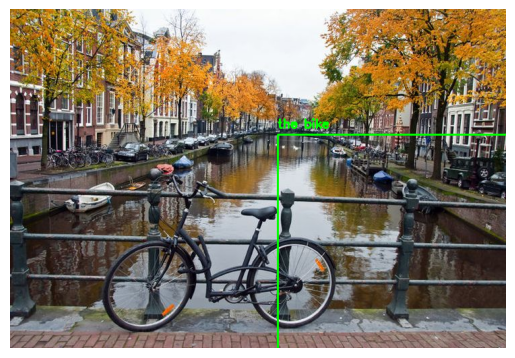

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Convert PIL → OpenCV (RGB → BGR)
cv_image = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)

# Your bounding boxes
bboxes = [
    {"box_2d": [397, 186, 951, 660], "label": "the bike"}
]

# Draw boxes
for item in bboxes:
    x1, y1, x2, y2 = item["box_2d"]
    label = item["label"]

    cv2.rectangle(cv_image, (x1, y1), (x2, y2), (0, 255, 0), 2)

    cv2.putText(
        cv_image,
        label,
        (x1, max(30, y1 - 10)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 255, 0),
        2
    )

# Convert back to RGB for display
rgb_image = cv2.cvtColor(cv_image, cv2.COLOR_BGR2RGB)

# Show in notebook
plt.imshow(rgb_image)
plt.axis("off")

# Preliminary conclusions


We tested Gemma 4:E2B on CPU for text, image and object detection. 

Both text (including multi-language) and image tests proved great performance. When asked to answer to a question in a foreign language, without being instructed to answer shortly, the model took long time to generate a long text sequence.

For object detection, the performance of the Gemma 4:E2B model is moderate, as it is shown as well in the tests on HuggingFace. We will conduct the similar test with the next size model as well (in another Notebook).
